In [2]:
%%writefile dataset.py
"""
Dataset class implementation for the cross-view user identification task.

This class handles loading and preprocessing of synchronized vehicle and UAV imagery,
including handling of bounding box coordinates and compass direction data.
"""

import os
import PIL
from pathlib import Path
import torch
from torch.utils.data import Dataset
import numpy as np
import pandas as pd
from torchvision.transforms import ToTensor, ToPILImage

# Skip the first 3 frames due to potential distortion in CARLA-generated images
# A total of 53 frames are generated, but the first 3 are excluded from processing
# The time interval between each frame is 0.2 seconds.

def get_numeric_part(filename):
    """
    Extract the numeric portion from the filename for consistent sorting.
    
    Args:
        filename (str): Filename to extract the number from
        
    Returns:
        int: Numeric value extracted from the filename stem
    """
    numPart = Path(filename).stem
    return int(numPart) if numPart else float('inf')

class CVdataset(Dataset):
    """
    Dataset class for handling synchronized vehicle and UAV imagery.
    
    Manages loading, preprocessing, and synchronization of:
    - Vehicle perspective images
    - UAV perspective images
    - Compass direction data
    - Bounding box coordinates
    
    Args:
        root (str): Root directory containing dataset files
        scenarioList (list): List of scenarios to process
        numRealizations (int): Number of realizations per scenario
        transform (tuple): Tuple of transforms for vehicle and UAV images
        rowGrid (tuple): Grid parameters for row coordinates (start, end, num_points)
        colGrid (tuple): Grid parameters for column coordinates (start, end, num_points)
        train (bool): Whether the dataset is being used for training
        trainSize (float): proportion of the dataset to include in the train split, and testSize is 1-trainSize.
        
    Attributes:
        vehImageList (list): List of vehicle perspective image paths
        uavImageList (list): List of UAV perspective image paths
        compassTheta (list): List of compass direction values (angles)
        BBoxCenters (list): List of bounding box center coordinates
    """
    
    def __init__(self, root, scenarioList, numRealizations, transform, 
                 rowGrid=(0,1023,0), colGrid=(0,1023,0), train=True, trainSize=0.9):
        self.root = Path(root)
        self.scenarioList = scenarioList
        self.numRealizations = numRealizations
        self.train = train
        self.trainSize = trainSize
        
        # Initialize grid points
        self.row = np.linspace(rowGrid[0], rowGrid[1], rowGrid[2])
        self.col = np.linspace(colGrid[0], colGrid[1], colGrid[2])
        
        # Initialize transforms with defaults if none provided
        self.vehImageTransform = transform[0] if transform else ToTensor()
        self.uavImageTransform = transform[1] if transform else ToTensor()
        
        # Initialize data storage lists
        self.vehImageList = []
        self.uavImageList = []
        self.compassTheta = []
        self.BBoxCenters = []
        
        # Load and process data for all scenarios and realizations
        self._load_dataset()
        
    def _load_dataset(self):
        """Internal method to load and preprocess dataset files."""
        for scenario in self.scenarioList:
            for realizationIdx in range(self.numRealizations):
                vehImageList = []
                uavImageList = []
                compassTheta = []
                BBoxCenters = []
                
                vehPath = self.root / f"{scenario}_{realizationIdx}" / f"{scenario}_{realizationIdx}" / "Vehicles"
                uavPath = self.root / f"{scenario}_{realizationIdx}" / f"{scenario}_{realizationIdx}" / "UAV"
                
                # Get the list of target vehicles
                targetVehicleList = [entry.name for entry in os.scandir(vehPath) 
                                   if entry.is_dir()]
                
                for targetVeh in targetVehicleList:
                    # Load vehicle tracking data (BBox center during time)
                    targetVehDataFrame = pd.read_csv(vehPath / (targetVeh+".csv"))
                    targetVehBBoxes = targetVehDataFrame.iloc[3:,5:7].to_numpy(dtype=np.float32)
                    
                    # Filter frames where the vehicle is within valid bounds (original image size is 1024x1024)
                    maskFrameFilter = np.logical_and(np.logical_and(targetVehBBoxes[:,0]>=4,targetVehBBoxes[:,0]<=1020),
                                                  np.logical_and(targetVehBBoxes[:,1]>=4,targetVehBBoxes[:,1]<=1020))
                    
                    # Sort and filter images, skipping the first 3 frames
                    sorted_files = np.array(sorted(list((uavPath / "sensor.camera.rgb").glob("*/*.png")),
                                                 key=get_numeric_part))[3:][maskFrameFilter]
                    uavImageList.extend(sorted_files)
                    
                    sorted_files = np.array(sorted(list((vehPath / targetVeh / "concatenated").glob("*.png")),
                                                 key=get_numeric_part))[3:][maskFrameFilter]
                    vehImageList.extend(sorted_files)
                    
                    compassTheta.extend(targetVehDataFrame.iloc[3:,1:2].to_numpy(dtype=np.float32)[maskFrameFilter])
                    
                    # Add target vehicle coordinates at first
                    BBoxes = np.expand_dims(targetVehBBoxes[maskFrameFilter], axis=1)
                    vehiclesList = [entry.name for entry in os.scandir(vehPath) 
                                  if not(entry.is_dir())]
                    
                    # Add other vehicle coordinates
                    for veh in vehiclesList:
                        if not (veh == targetVeh + '.csv'):
                            vehDataFrame = pd.read_csv(vehPath / veh)
                            vehBBox = np.expand_dims(vehDataFrame.iloc[3:,5:7].to_numpy(dtype=np.float32)[maskFrameFilter], axis=1)
                            BBoxes = np.concatenate((BBoxes,vehBBox), axis=1)
                    
                    # In training mode, add grid points for model learning
                    if self.train:
                        for row in self.row:
                            for col in self.col:
                                gridPoint = np.repeat(np.expand_dims(np.array([[row, col]], dtype=np.float32), axis=0),
                                                    targetVehBBoxes[maskFrameFilter].shape[0],axis=0)
                                BBoxes = np.concatenate((BBoxes,gridPoint), axis=1)
                    
                    BBoxCenters.extend(list(BBoxes))
                    
                # Split dataset to Train and Validation subset    
                index_split = int(len(vehImageList)*self.trainSize)
                if self.train:
                    self.vehImageList.extend(vehImageList[0:index_split])
                    self.uavImageList.extend(uavImageList[0:index_split])
                    self.compassTheta.extend(compassTheta[0:index_split])
                    self.BBoxCenters.extend(BBoxCenters[0:index_split])
                else:
                    self.vehImageList.extend(vehImageList[index_split:])
                    self.uavImageList.extend(uavImageList[index_split:])
                    self.compassTheta.extend(compassTheta[index_split:])
                    self.BBoxCenters.extend(BBoxCenters[index_split:])
    
        self.data_size = len(self.vehImageList)
    
    def __len__(self):
        """Return total number of samples in dataset."""
        return self.data_size
    
    def __getitem__(self, idx):
        """
        Retrieve and preprocess a sample from the dataset.
        
        Args:
            idx (int): Index of sample to retrieve
            
        Returns:
            tuple: (vehicle_image, uav_image, compass_theta, bbox_centers)
        """
        # Load and convert images to RGB format
        vehImage = PIL.Image.open(os.path.join(self.vehImageList[idx]))
        uavImage = PIL.Image.open(os.path.join(self.uavImageList[idx]))
        vehImage = vehImage.convert('RGB')
        uavImage = uavImage.convert('RGB')
        
        # Apply transformations
        vehImage = self.vehImageTransform(vehImage)
        uavImage = self.uavImageTransform(uavImage)
        
        # Convert remaining data to tensors
        compassTheta = torch.from_numpy(self.compassTheta[idx])
        BBoxCenters = torch.from_numpy(self.BBoxCenters[idx])
        
        return vehImage, uavImage, compassTheta, BBoxCenters

Writing dataset.py


In [1]:
%%writefile dataset_kaggle.py
"""
Dataset class implementation for the cross-view user identification task.

This class handles loading and preprocessing of synchronized vehicle and UAV imagery,
including handling of bounding box coordinates and compass direction data.
"""

import os
import PIL
from pathlib import Path
import torch
from torch.utils.data import Dataset
import numpy as np
import pandas as pd
from torchvision.transforms import ToTensor, ToPILImage

# Skip the first 3 frames due to potential distortion in CARLA-generated images
# A total of 53 frames are generated, but the first 3 are excluded from processing
# The time interval between each frame is 0.2 seconds.

def get_numeric_part(filename):
    """
    Extract the numeric portion from the filename for consistent sorting.
    
    Args:
        filename (str): Filename to extract the number from
        
    Returns:
        int: Numeric value extracted from the filename stem
    """
    numPart = Path(filename).stem
    return int(numPart) if numPart else float('inf')

class CVdataset(Dataset):
    """
    Dataset class for handling synchronized vehicle and UAV imagery.
    
    Manages loading, preprocessing, and synchronization of:
    - Vehicle perspective images
    - UAV perspective images
    - Compass direction data
    - Bounding box coordinates
    
    Args:
        root (str): Root directory containing dataset files
        scenarioList (list): List of scenarios to process
        numRealizations (int): Number of realizations per scenario
        transform (tuple): Tuple of transforms for vehicle and UAV images
        rowGrid (tuple): Grid parameters for row coordinates (start, end, num_points)
        colGrid (tuple): Grid parameters for column coordinates (start, end, num_points)
        train (bool): Whether the dataset is being used for training
        trainSize (float): proportion of the dataset to include in the train split, and testSize is 1-trainSize.
        
    Attributes:
        vehImageList (list): List of vehicle perspective image paths
        uavImageList (list): List of UAV perspective image paths
        compassTheta (list): List of compass direction values (angles)
        BBoxCenters (list): List of bounding box center coordinates
    """
    
    def __init__(self, root, scenarioList, numRealizations, transform, 
                 rowGrid=(0,1023,0), colGrid=(0,1023,0), train=True, trainSize=0.9):
        self.root = Path(root)
        self.scenarioList = scenarioList
        self.numRealizations = numRealizations
        self.train = train
        self.trainSize = trainSize
        
        # Initialize grid points
        self.row = np.linspace(rowGrid[0], rowGrid[1], rowGrid[2])
        self.col = np.linspace(colGrid[0], colGrid[1], colGrid[2])
        
        # Initialize transforms with defaults if none provided
        self.vehImageTransform = transform[0] if transform else ToTensor()
        self.uavImageTransform = transform[1] if transform else ToTensor()
        
        # Initialize data storage lists
        self.vehImageList = []
        self.uavImageList = []
        self.compassTheta = []
        self.BBoxCenters = []
        
        # Load and process data for all scenarios and realizations
        self._load_dataset()
        
    def _load_dataset(self):
        """Internal method to load and preprocess dataset files."""
        for scenario in self.scenarioList:
            for realizationIdx in range(self.numRealizations):
                vehImageList = []
                uavImageList = []
                compassTheta = []
                BBoxCenters = []
                
                vehPath = self.root / f"{scenario}_{realizationIdx}" / f"{scenario}_{realizationIdx}" / "Vehicles"
                uavPath = self.root / f"{scenario}_{realizationIdx}" / f"{scenario}_{realizationIdx}" / "UAV"
                
                # Get the list of target vehicles
                targetVehicleList = [entry.name for entry in os.scandir(vehPath) 
                                   if entry.is_dir()]
                
                for targetVeh in targetVehicleList:
                    # Load vehicle tracking data (BBox center during time)
                    targetVehDataFrame = pd.read_csv(vehPath / (targetVeh+".csv"))
                    targetVehBBoxes = targetVehDataFrame.iloc[3:,5:7].to_numpy(dtype=np.float32)
                    
                    # Filter frames where the vehicle is within valid bounds (original image size is 1024x1024)
                    maskFrameFilter = np.logical_and(np.logical_and(targetVehBBoxes[:,0]>=4,targetVehBBoxes[:,0]<=1020),
                                                  np.logical_and(targetVehBBoxes[:,1]>=4,targetVehBBoxes[:,1]<=1020))
                    
                    # Sort and filter images, skipping the first 3 frames
                    sorted_files = np.array(sorted(list((uavPath / "sensor.camera.rgb").glob("*/*.png")),
                                                 key=get_numeric_part))[3:][maskFrameFilter]
                    uavImageList.extend(sorted_files)
                    
                    sorted_files = np.array(sorted(list((vehPath / targetVeh / "concatenated").glob("*.png")),
                                                 key=get_numeric_part))[3:][maskFrameFilter]
                    vehImageList.extend(sorted_files)
                    
                    compassTheta.extend(targetVehDataFrame.iloc[3:,1:2].to_numpy(dtype=np.float32)[maskFrameFilter])
                    
                    # Add target vehicle coordinates at first
                    BBoxes = np.expand_dims(targetVehBBoxes[maskFrameFilter], axis=1)
                    vehiclesList = [entry.name for entry in os.scandir(vehPath) 
                                  if not(entry.is_dir())]
                    
                    # Add other vehicle coordinates
                    for veh in vehiclesList:
                        if not (veh == targetVeh + '.csv'):
                            vehDataFrame = pd.read_csv(vehPath / veh)
                            vehBBox = np.expand_dims(vehDataFrame.iloc[3:,5:7].to_numpy(dtype=np.float32)[maskFrameFilter], axis=1)
                            BBoxes = np.concatenate((BBoxes,vehBBox), axis=1)
                    
                    # In training mode, add grid points for model learning
                    if self.train:
                        for row in self.row:
                            for col in self.col:
                                gridPoint = np.repeat(np.expand_dims(np.array([[row, col]], dtype=np.float32), axis=0),
                                                    targetVehBBoxes[maskFrameFilter].shape[0],axis=0)
                                BBoxes = np.concatenate((BBoxes,gridPoint), axis=1)
                    
                    BBoxCenters.extend(list(BBoxes))
                    
                # Split dataset to Train and Validation subset    
                index_split = int(len(vehImageList)*self.trainSize)
                if self.train:
                    self.vehImageList.extend(vehImageList[0:index_split])
                    self.uavImageList.extend(uavImageList[0:index_split])
                    self.compassTheta.extend(compassTheta[0:index_split])
                    self.BBoxCenters.extend(BBoxCenters[0:index_split])
                else:
                    self.vehImageList.extend(vehImageList[index_split:])
                    self.uavImageList.extend(uavImageList[index_split:])
                    self.compassTheta.extend(compassTheta[index_split:])
                    self.BBoxCenters.extend(BBoxCenters[index_split:])
    
        self.data_size = len(self.vehImageList)
    
    def __len__(self):
        """Return total number of samples in dataset."""
        return self.data_size
    
    def __getitem__(self, idx):
        """
        Retrieve and preprocess a sample from the dataset.
        
        Args:
            idx (int): Index of sample to retrieve
            
        Returns:
            tuple: (vehicle_image, uav_image, compass_theta, bbox_centers)
        """
        # Load and convert images to RGB format
        vehImage = PIL.Image.open(os.path.join(self.vehImageList[idx]))
        uavImage = PIL.Image.open(os.path.join(self.uavImageList[idx]))
        vehImage = vehImage.convert('RGB')
        uavImage = uavImage.convert('RGB')
        
        # Apply transformations
        vehImage = self.vehImageTransform(vehImage)
        uavImage = self.uavImageTransform(uavImage)
        
        # Convert remaining data to tensors
        compassTheta = torch.from_numpy(self.compassTheta[idx])
        BBoxCenters = torch.from_numpy(self.BBoxCenters[idx])
        
        return vehImage, uavImage, compassTheta, BBoxCenters

Writing dataset_kaggle.py


In [18]:
root = 'I:\\PhD Codes\\Final Dataset New'
scenarioList = ['FiveWays', 'FourWays', 'Park', 'Roundabout', 'StraightRoad', 'TJunction']
numRealizations = 3
Height=256
Width=1280
Length=1024
train = True

In [14]:
from torchvision import transforms
import torch
vehImageTransform = transforms.Compose([
    transforms.Resize([Height, Width]),
    transforms.ToTensor(),
    #transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
    
])

uavImageTransform = transforms.Compose([
    transforms.Resize([Length, Length]),
    transforms.ToTensor(),
    #transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
    
])

In [15]:
from dataset import CVdataset

In [19]:
cvDataset_train = CVdataset(root=root,
                            scenarioList=scenarioList,
                            numRealizations=numRealizations,
                            transform=(vehImageTransform, uavImageTransform),
                            train=train)

In [6]:
cvDataset_test = CVdataset(root=root,
                           scenarioList=scenarioList,
                           numRealizations=numRealizations,
                           transform=(vehImageTransform, uavImageTransform),
                           train=not(train))

In [20]:
len(cvDataset_train)

20897

In [8]:
vehImage1, uavImage1, compassTheta1, BBoxCenters1 = cvDataset_train[900]
vehImage2, uavImage2, compassTheta2, BBoxCenters2 = cvDataset_test[900]

In [9]:
vehImage1.shape, uavImage1.shape, compassTheta1.shape, BBoxCenters1.shape

(torch.Size([3, 256, 1280]),
 torch.Size([3, 1024, 1024]),
 torch.Size([1]),
 torch.Size([130, 2]))

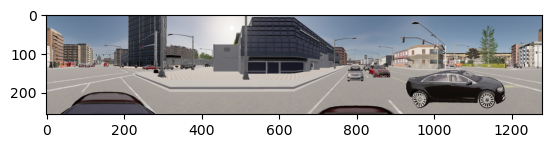

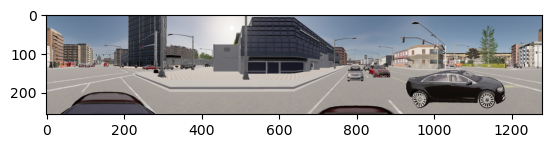

In [10]:
import matplotlib.pyplot as plt
plt.figure()
plt.imshow(vehImage1.permute(1,2,0).numpy())
plt.figure()
plt.imshow(vehImage2.permute(1,2,0).numpy())

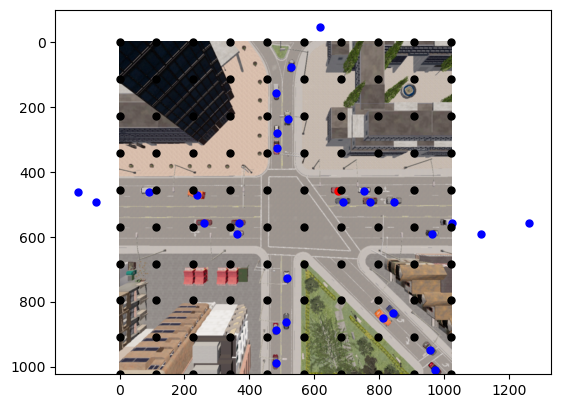

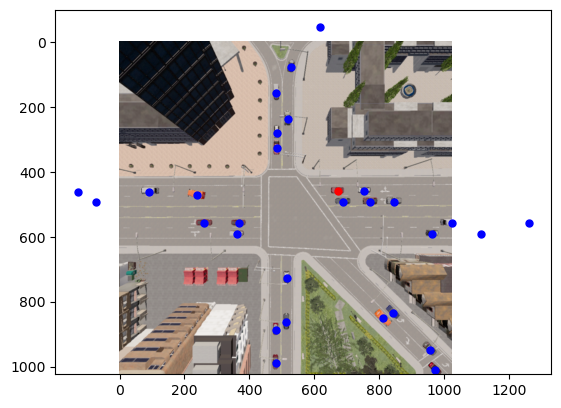

In [11]:
plt.figure()
plt.imshow(uavImage1.permute(1,2,0).numpy())
for i in range(len(BBoxCenters1)):
    if i==0:
        plt.plot(BBoxCenters1[i,0], BBoxCenters1[i,1], 'ro', markersize=5)
    elif i>29:
        plt.plot(BBoxCenters1[i,0], BBoxCenters1[i,1], 'ko', markersize=5)
    else:
        plt.plot(BBoxCenters1[i,0], BBoxCenters1[i,1], 'bo', markersize=5)

plt.figure()
plt.imshow(uavImage2.permute(1,2,0).numpy())
for i in range(len(BBoxCenters2)):
    if i==0:
        plt.plot(BBoxCenters2[i,0], BBoxCenters2[i,1], 'ro', markersize=5)
    elif i>29:
        plt.plot(BBoxCenters2[i,0], BBoxCenters2[i,1], 'ko', markersize=5)
    else:
        plt.plot(BBoxCenters2[i,0], BBoxCenters2[i,1], 'bo', markersize=5)

In [1]:
import numpy as np

In [3]:
np.linspace(0, 1023, 8)

array([   0.        ,  146.14285714,  292.28571429,  438.42857143,
        584.57142857,  730.71428571,  876.85714286, 1023.        ])

In [4]:
a = list([0,1,2,3,4,5,6,7,8,9])
i = np.arange(10)

In [6]:
a[0:8], a[8:]

([0, 1, 2, 3, 4, 5, 6, 7], [8, 9])